In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

import geopandas as gpd
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import warnings
warnings.filterwarnings("ignore")

In [2]:
raw_path = Path("../data/raw/era5")

ds_instant = xr.open_dataset(raw_path / "era5_2022_07_instant.nc", engine="netcdf4")
ds_accum = xr.open_dataset(raw_path / "era5_2022_07_accum.nc", engine="netcdf4")

ds = xr.merge([ds_instant, ds_accum])

In [3]:
print("Variables:", list(ds.data_vars))
print("Dimensions:", dict(ds.dims))
print("Lat range:", float(ds.latitude.min()), "to", float(ds.latitude.max()))
print("Lon range:", float(ds.longitude.min()), "to", float(ds.longitude.max()))
print("Time steps:", len(ds.valid_time))
print("First timestamp:", ds.valid_time.values[0])
print("Last timestamp:", ds.valid_time.values[-1])

Variables: ['t2m', 'd2m', 'u10', 'v10', 'sp', 'swvl1', 'tp']
Dimensions: {'valid_time': 124, 'latitude': 33, 'longitude': 53}
Lat range: 36.0 to 44.0
Lon range: -9.5 to 3.5
Time steps: 124
First timestamp: 2022-07-01T00:00:00.000000000
Last timestamp: 2022-07-31T18:00:00.000000000


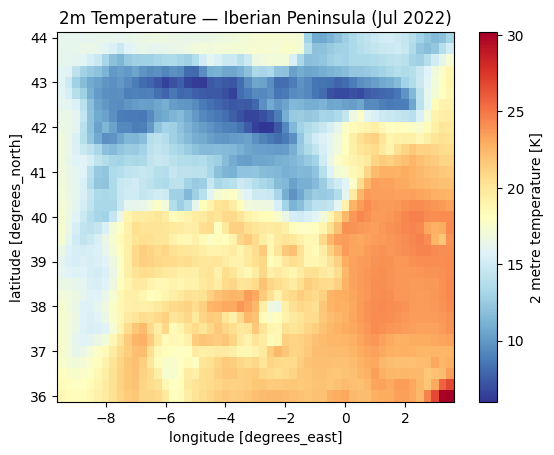

In [4]:
temp = ds["t2m"].isel(valid_time=0) - 273.15
temp.plot(cmap = "RdYlBu_r") # type: ignore
plt.title("2m Temperature — Iberian Peninsula (Jul 2022)")
plt.show()

In [6]:
# Load fire data
firms_path = Path("../data/raw/firms/firms_2022_07.csv")
fires = pd.read_csv(firms_path)
print(fires.head())
print("Columns:", fires.columns.tolist())

   latitude  longitude  bright_ti4  scan  track    acq_date  acq_time  \
0  39.93546   -3.74398      301.12  0.45   0.39  2022-07-01       224   
1  39.93785   -3.74533      308.41  0.45   0.39  2022-07-01       224   
2  39.93896   -3.74284      301.26  0.45   0.39  2022-07-01       224   
3  40.01023   -3.90084      299.94  0.45   0.39  2022-07-01       224   
4  41.17016   -7.89123      295.93  0.39   0.36  2022-07-01       224   

  satellite instrument confidence  version  bright_ti5   frp daynight  type  
0         N      VIIRS          n        2      289.25  0.84        N     2  
1         N      VIIRS          n        2      289.54  1.67        N     2  
2         N      VIIRS          n        2      289.08  0.84        N     0  
3         N      VIIRS          n        2      289.82  0.54        N     2  
4         N      VIIRS          n        2      283.66  0.38        N     0  
Columns: ['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_date', 'acq_time', 'sa

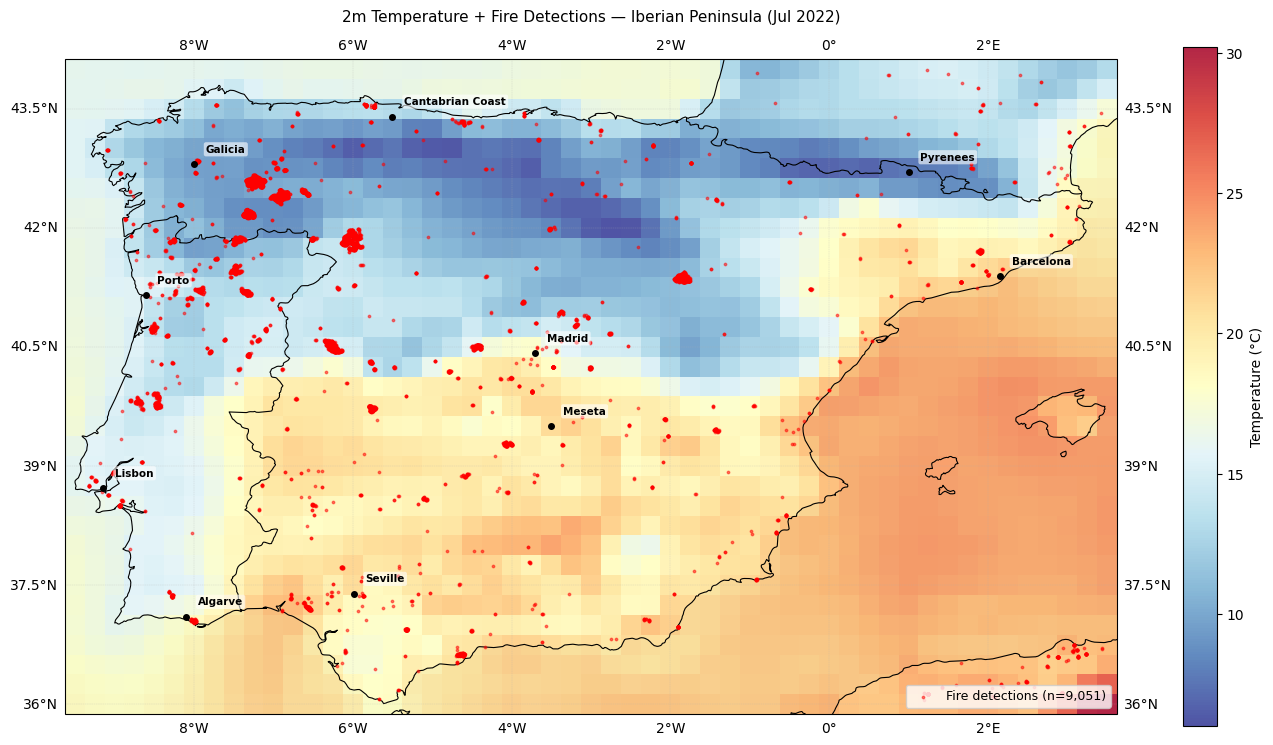

In [9]:
# Key locations to annotate
locations = {
    "Lisbon": (-9.14, 38.72),
    "Porto": (-8.61, 41.15),
    "Madrid": (-3.70, 40.42),
    "Seville": (-5.99, 37.39),
    "Barcelona": (2.15, 41.39),
    "Galicia": (-8.0, 42.8),
    "Algarve": (-8.1, 37.1),
    "Meseta": (-3.5, 39.5),
    "Pyrenees": (1.0, 42.7),
    "Cantabrian Coast": (-5.5, 43.4),
}

firms_path = Path("../data/raw/firms/firms_2022_07.csv")
fires = pd.read_csv(firms_path)

fig, ax = plt.subplots(
    figsize=(14, 10),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

# Temperature layer
temp = ds["t2m"].isel(valid_time=0) - 273.15
temp.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="RdYlBu_r",
    alpha=0.85,
    add_colorbar=True,
    cbar_kwargs={"label": "Temperature (°C)", "shrink": 0.7}
)

# Fire points
ax.scatter(
    fires["longitude"],
    fires["latitude"],
    c="red",
    s=3,
    alpha=0.5,
    transform=ccrs.PlateCarree(),
    label=f"Fire detections (n={len(fires):,})",
    zorder=5
)

# City markers
for name, (lon, lat) in locations.items():
    ax.plot(
        lon, lat,
        marker="o",
        color="black",
        markersize=4,
        transform=ccrs.PlateCarree(),
        zorder=6
    )
    ax.text(
        lon + 0.15, lat + 0.15,
        name,
        fontsize=7.5,
        fontweight="bold",
        color="black",
        transform=ccrs.PlateCarree(),
        zorder=7,
        bbox=dict(
            facecolor="white",
            alpha=0.6,
            edgecolor="none",
            boxstyle="round,pad=0.2"
        )
    )

# Map features
ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor="black")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.OCEAN, facecolor="lightblue", alpha=0.4)
ax.gridlines(draw_labels=True, linewidth=0.3, linestyle="--", alpha=0.5)

plt.title(
    "2m Temperature + Fire Detections — Iberian Peninsula (Jul 2022)",
    fontsize=11,
    pad=12
)
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
# plt.savefig("../data/external/iberia_fire_map_july2022.png", dpi=150, bbox_inches="tight")
plt.show()

VIIRS SNPP fire detections overlaid on surface temperature for July 2022. The spatial distribution challenges a simple temperature-threshold assumption; the densest fire clusters appear in northwest Portugal and Galicia, a transitional zone between cool Atlantic air and warmer inland conditions, rather than in the hottest southern interior. This supports the project's core hypothesis that compounding atmospheric conditions (humidity gradients, wind shifts, prolonged dryness) are stronger ignition predictors than peak temperature alone. The fuel-sparse Meseta shows relatively few detections despite recording the highest temperatures.